# Simulate traps


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines


import sys, os, importlib, json
sys.path.append( os.path.abspath(os.path.join('..')) )

import warnings
warnings.filterwarnings('ignore')

import methods.simulations as sim
import utils.utils as gen_utils

# Opening config file
f = open('../fpaths_config.json')
paths = json.load(f)

nn_path = paths['nn_preds']
trap_sims_path = paths['trap_simulations']
misc_figures_path = paths['misc_figures_path']

ModuleNotFoundError: No module named 'methods'

In [ ]:
importlib.reload(sim)

locs = {'Ceiba': (0.00048, 0.5, 8)}

for loc, vals in locs.items():
    model = 'finetuned_noise_10'

    df = sim.format_mols_data(nn_path, model)
    poisson_p, negbin_p, prop = vals

    poisson = sim.poisson_sim(poisson_p, df.copy(deep=True))
    poisson = poisson.iloc[1:-1,:]

    seen_prop = prop/np.average(df.MoLS)
    negbin = sim.negbin_sim(negbin_p, seen_prop, df.copy(deep=True))
    negbin  = negbin.iloc[1:-1,:]

    poisson.to_csv('{}/{}_poisson.csv'.format(trap_sims_path, loc), index=False)
    negbin.to_csv('{}/{}_negbin.csv'.format(trap_sims_path, loc), index=False)
    print('{} complete'.format(loc))


Ceiba complete


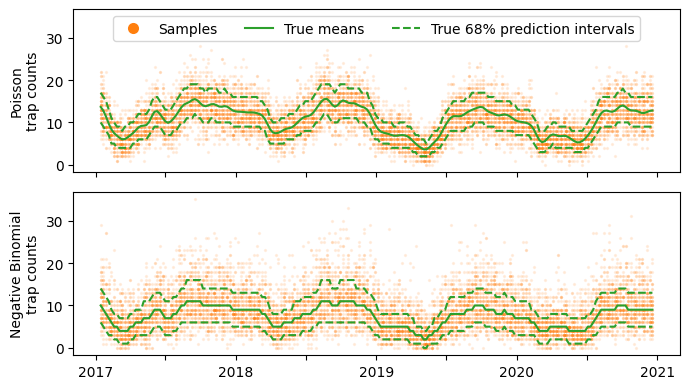

In [16]:
importlib.reload(sim)
poisson_p, negbin_p, prop = (0.00048, 0.5, 8)


data_path = '../data/Trap_sims'
locs, _ = gen_utils.collect_locs_dists()
fig, axs = plt.subplots(2, figsize=(7,4), sharex=True, sharey=True)

poisson = pd.read_csv('{}/Ceiba_poisson.csv'.format(data_path))
poisson['Datetime'] = pd.to_datetime(poisson['Datetime'])
mu_poisson, u_quant_poisson, l_quant_poisson = sim.true_poisson_params(poisson_p, poisson)

[axs[0].scatter(poisson.Datetime, poisson[mols_col], s=2, color='tab:orange', alpha=0.1) for mols_col in sim.sim_cols(50)]
axs[0].plot(poisson.Datetime, mu_poisson, color='tab:green', alpha=1, label='True means')#,\n{}'.format(r'$(E[C_w])$'))
axs[0].plot(poisson.Datetime, u_quant_poisson, linestyle='--', color='tab:green', alpha=1, label='True 68% prediction intervals')#,\n{}'.format(r'$([l_{w,0.68}, u_{w,0.68}])$'))
axs[0].plot(poisson.Datetime, l_quant_poisson, linestyle='--', color='tab:green', alpha=1)

axs[0].set_ylabel('Poisson\ntrap counts')

#Next Neg Bin
negbin = pd.read_csv('{}/Ceiba_negbin.csv'.format(data_path))
seen_prop = prop/np.average(negbin.MoLS)*negbin.MoLS
negbin['Datetime'] = pd.to_datetime(negbin['Datetime'])
mu_negbin, u_quant_negbin, l_quant_negbin = sim.negbin_params(negbin_p, seen_prop)

[axs[1].scatter(negbin.Datetime, negbin[mols_col], s=2, color='tab:orange', alpha=0.1) for mols_col in sim.sim_cols(50)]
axs[1].plot(negbin.Datetime, mu_negbin, color='tab:green', alpha=1, label='True means')#,\n{}'.format(r'$E[C_w]$'))
axs[1].plot(negbin.Datetime, u_quant_negbin, linestyle='--', color='tab:green', alpha=1, label='True 68% prediction intervals')#,\n{}'.format(r'$[l_{w,0.68}, u_{w,0.68}]$'))
axs[1].plot(negbin.Datetime, l_quant_negbin, linestyle='--', color='tab:green', alpha=1)

axs[1].set_ylabel('Negative Binomial\ntrap counts')
#axs[1].legend(loc='upper left')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Hide every other x tick label
for j, label in enumerate(axs[1].get_xticklabels()):
    if j % 2 != 0:
        label.set_visible(False)

# Create a custom legend handle for 'Trap samples' (larger and darker)
trap_sample_handle = mlines.Line2D([], [], marker='o', color='tab:orange', linestyle='None', markerfacecolor='tab:orange',
                            markeredgewidth=0, markersize=8, label='Samples')#,\n{}'.format(r'$(c_{i,w})$'))

# Collect handles and labels from one of the axes
handles, labels = axs[0].get_legend_handles_labels()

# Add the custom legend handle to the list
handles = [trap_sample_handle] + handles
labels = ['Samples'] + labels #,\n{}'.format(r'$(c_{i,w})$')] + labels

# Add a single legend to the right of all subplots
#fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.17, -0.05), fontsize='medium', ncol=3)
axs[0].legend(handles, labels, loc='upper center', ncol=3)           

fig.tight_layout()
fig.savefig('{}/simulated_traps_raw.png'.format(misc_figures_path), dpi=300, bbox_inches='tight')
plt.show()


true_params = pd.DataFrame({'Datetime': negbin.Datetime, 'MoLS': negbin.MoLS, 'poisson_p': poisson_p, 'negbin_p': negbin_p, 'negbin_seen_prop': seen_prop})
true_params.to_csv('{}/true_parameters.csv'.format(trap_sims_path), index=False)

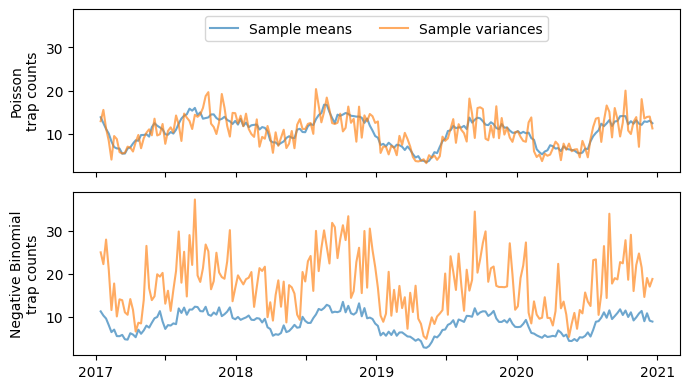

In [14]:
data_path = '../data/Trap_sims'
locs, _ = gen_utils.collect_locs_dists()
fig, axs = plt.subplots(2, figsize=(7,4), sharex=True, sharey=True)

poisson = pd.read_csv('{}/Ceiba_poisson.csv'.format(data_path))
poisson['Datetime'] = pd.to_datetime(poisson['Datetime'])

axs[0].plot(poisson.Datetime, poisson.Ref, color='tab:blue', alpha=0.65, label='Sample means')#, {}'.format(r'$\mu(C_w)$'))
axs[0].plot(poisson.Datetime, poisson.Ref_sd**2, color='tab:orange', alpha=0.65, label='Sample variances')#, {}'.format(r'$\sigma^2(C_w)$'))
axs[0].set_ylabel('Poisson\ntrap counts')
#axs[0].legend(loc='upper left')
#axs[0].set_title('Statistics of simulated traps for Arboleda')

#Next Neg Bin
negbin = pd.read_csv('{}/Ceiba_negbin.csv'.format(data_path))
negbin['Datetime'] = pd.to_datetime(negbin['Datetime'])

axs[1].plot(negbin.Datetime, negbin.Ref, color='tab:blue', alpha=0.65)
axs[1].plot(negbin.Datetime, negbin.Ref_sd**2, color='tab:orange', alpha=0.65)
axs[1].set_ylabel('Negative Binomial\ntrap counts')
#axs[1].legend(loc='upper left')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Hide every other x tick label
for j, label in enumerate(axs[1].get_xticklabels()):
    if j % 2 != 0:
        label.set_visible(False)

# Collect handles and labels from one of the axes
handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend(loc='upper center', ncol=2)

# Add a single legend to the right of all subplots
#fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.2, -0.05), fontsize='medium', ncol=2)

fig.tight_layout()
fig.savefig('{}/simulated_traps_stats_Ceiba.png'.format(misc_figures_path), dpi=300, bbox_inches='tight')
plt.show()